# Uncertainty Quantification in neutron spectrum unfolding (CUQIpy)

This notebook mirrors the CUQIpy tutorial
[*Uncertainty Quantification in one-dimensional deconvolution*](https://cuqi-dtu.github.io/CUQIpy/user/_auto_howtos/uq_in_deconvolution_1d.html)
— but for **Bonner sphere neutron spectrum unfolding** with `bssunfold`.

Instead of a single point estimate we treat the unknown spectrum as a
random variable, place a smoothness prior on it, and **sample the full
Bayesian posterior** with the [CUQIpy](https://github.com/CUQI-DTU/CUQIpy)
library (DTU). The posterior samples give per-bin credible intervals that
quantify how well each energy region is informed by the 10 Bonner sphere
readings.

The benchmark data are the **Monte-Carlo calculated spectrum
`ISO_ref_AmB`** from the
[IAEA spectral unfolding compendium](https://www-nds.iaea.org/benchmarks/)
(thermal group, epithermal $1/E$ tail, and a broad fast peak),
folded through the built-in GSF response functions.

**Requires:** `pip install bssunfold[cuqi]` (or `pip install cuqipy`).

## Setup

In [1]:
import warnings

warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import cuqi

from bssunfold import CUQI_AVAILABLE, Detector, RF_GSF
from bssunfold.utils.comparison import compare_spectra

assert CUQI_AVAILABLE, "cuqipy is required: pip install bssunfold[cuqi]"
print("cuqi version:", cuqi.__version__)

cuqi version: 1.5.1


## Setting up the forward model

A Bonner Sphere Spectrometer measures *sphere readings* — fluence-to-response
integrals over broad energy windows. The forward model is the linear
Fredholm equation of the first kind

$$
b_i = \sum_j A_{ij}\, \varphi_j, \qquad i = 1,\dots,10,
$$

with the response matrix $A$ ($10 \times 60$, built-in GSF responses on the
1e-9 – 631 MeV grid) and the unknown fluence spectrum $\varphi$.

Response matrix A: 10 spheres x 60 energy bins
Energy grid: 1.0e-09 - 631.0 MeV (60 bins)


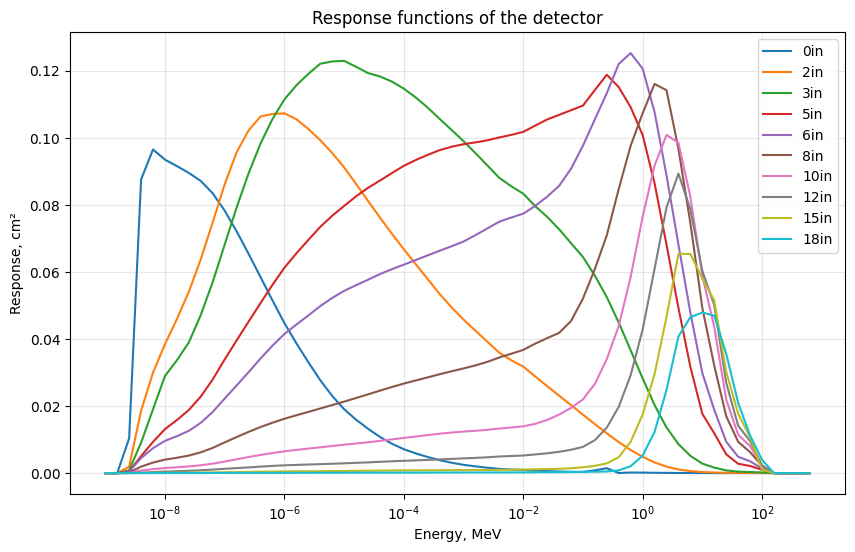

In [2]:
detector = Detector(RF_GSF)
E = detector.E_MeV
names = detector.detector_names

# response matrix A: rows = spheres, columns = energy bins
A = np.stack([detector.sensitivities[n] for n in names])
print(f"Response matrix A: {A.shape[0]} spheres x {A.shape[1]} energy bins")
print(f"Energy grid: {E[0]:.1e} - {E[-1]:.1f} MeV ({len(E)} bins)")

detector.plot_response_functions()

## Setting the data: IAEA Monte-Carlo spectrum → synthetic readings

The compendium CSV stores the Monte-Carlo spectra on their own 61-point
energy grid. We interpolate `ISO_ref_AmB` onto the 60-bin detector grid,
fold it through the response matrix, and add 3% Gaussian noise — the
resulting readings are the "measurements" to be unfolded.

Effective readings (noisy):
       0in: 0.0001843
       2in: 0.004619
       3in: 0.03356
       5in: 0.162
       6in: 0.192
       8in: 0.243
      10in: 0.2228
      12in: 0.1708
      15in: 0.1023
      18in: 0.05335


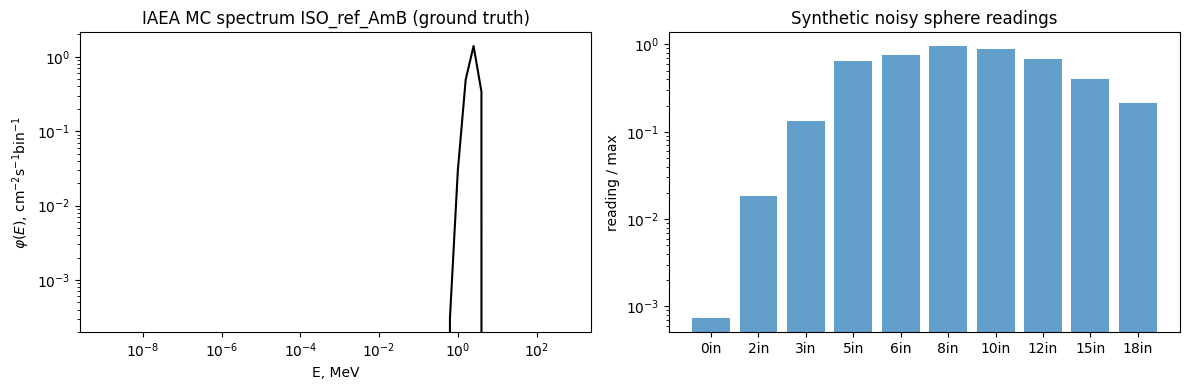

In [3]:
reference_csv = pd.read_csv(
    "../tests/MonteCarlo_Calculated_spectra_from_IAEA_Comp_for_comparison.csv"
)
phi_true = np.interp(E, reference_csv["E_MeV"].values,
                     reference_csv["ISO_ref_AmB"].values)

rng = np.random.default_rng(42)
noise_rel = 0.03
b_exact = np.array([detector.sensitivities[n] @ phi_true for n in names])
b_noisy = b_exact * (1.0 + rng.normal(0, noise_rel, b_exact.size))

readings = {n: float(v) for n, v in zip(names, b_noisy)}

print("Effective readings (noisy):")
for n in names:
    print(f"  {n:>8s}: {readings[n]:.4g}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ax = axes[0]
ax.loglog(E, phi_true, "k-", lw=1.5)
ax.set(xlabel="E, MeV", ylabel=r"$\varphi(E)$, cm$^{-2}$s$^{-1}$bin$^{-1}$",
       title="IAEA MC spectrum ISO_ref_AmB (ground truth)")
ax = axes[1]
ax.bar(range(len(names)), b_noisy / b_exact.max(), color="C0", alpha=0.7)
ax.set(xticks=range(len(names)), xticklabels=names, ylabel="reading / max",
       title="Synthetic noisy sphere readings")
ax.set_yscale("log")
plt.tight_layout();

## Setting up the prior

The spectrum is smooth on the log-energy axis, so we place a
**Gaussian Markov random field (GMRF)** prior on it — a Gaussian with a
sparse precision matrix built from first-order differences that penalises
wiggles. The prior mean is the non-negative least-squares solution
(a data-driven, always non-negative center):

$$
\varphi \sim \text{GMRF}(\mu_{\text{NNLS}},\; \delta), \qquad
\delta = 200 .
$$

In [4]:
from scipy.optimize import nnls

mu_nnls, _ = nnls(A, b_noisy)
mu_nnls = np.maximum(mu_nnls, 1e-30)

x = cuqi.distribution.GMRF(mu_nnls, 200)
print(x)

CUQI GMRF.


## Setting up the likelihood

The 3% measurement noise is modelled as i.i.d. Gaussian on the readings.
CUQI composes the linear forward model with the random variable `x` via
the `@` operator — exactly like `A @ x` in the deconvolution tutorial:

$$
b \mid \varphi \sim \mathcal{N}(A\varphi,\; \sigma^2 I),
\qquad \sigma = 0.03 .$$

In [5]:
Alin = cuqi.model.LinearModel(A)
print(Alin)

y = cuqi.distribution.Gaussian(Alin @ x, noise_rel**2)
print(y)

CUQI LinearModel: _DefaultGeometry1D[60] -> _DefaultGeometry1D[10].
    Forward parameters: ['x'].
CUQI Gaussian. Conditioning variables ['x'].


## Bayesian problem (joint distribution)

Combining the likelihood and the prior gives the joint distribution
$p(b, \varphi) = p(b \mid \varphi)\, p(\varphi)$:

In [6]:
BP = cuqi.problem.BayesianProblem(y, x)
print(BP)

BayesianProblem with target: 
 JointDistribution(
    Equation: 
	p(y,x) = p(y|x)p(x)
    Densities: 
	y ~ CUQI Gaussian. Conditioning variables ['x'].
	x ~ CUQI GMRF.
 )


## Setting the data (posterior)

Conditioning on the observed readings turns the joint distribution into
the posterior $p(\varphi \mid b)$:

In [7]:
BP.set_data(y=b_noisy)
print(BP)

BayesianProblem with target: 
 Posterior(
    Equation:
	 p(x|y) ∝ L(x|y)p(x)
    Densities:
	y ~ CUQI Gaussian Likelihood function. Parameters ['x'].
 	x ~ CUQI GMRF.
 )


## Sampling from the posterior

`sample_posterior` automatically selects a sampler for the Gaussian-GMRF
pair — the **LinearRTO** sampler, a robust linearised random-traverse
algorithm that handles the strongly correlated unfolding posterior well:

In [8]:
samples = BP.sample_posterior(2000)
print(samples)

!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
!!! Automatic sampler selection is a work-in-progress. !!!
!!!       Always validate the computed results.        !!!
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!

Using cuqi.sampler LinearRTO sampler.
burn-in: 20%


Sample:   0%|          | 0/2000 [00:00<?, ?it/s]

Sample:   0%|          | 0/2000 [00:00<?, ?it/s, acc rate: 100.00%]

Sample:   0%|          | 0/2000 [00:00<?, ?it/s, acc rate: 100.00%]

Sample:   0%|          | 0/2000 [00:00<?, ?it/s, acc rate: 100.00%]

...

Sample:  98%|█████████▊| 1969/2000 [00:05<00:00, 352.76it/s, acc rate: 100.00%]

Sample:  98%|█████████▊| 1969/2000 [00:05<00:00, 352.76it/s, acc rate: 100.00%]

Sample:  98%|█████████▊| 1969/2000 [00:05<00:00, 352.76it/s, acc rate: 100.00%]

Sample: 100%|██████████| 2000/2000 [00:05<00:00, 374.84it/s, acc rate: 100.00%]

Elapsed time: 6.388785123825073
CUQIpy Samples:
---------------

Ns (number of samples):
 2000

Geometry:
 _DefaultGeometry1D[60]

Shape:
 (60, 2000)

Samples:
 [[-0.05279787  0.04399989 -0.05680931 ... -0.18752553  0.05861077
  -0.09153325]
 [-0.12125385  0.04027677  0.05242201 ... -0.07724004  0.10871966
  -0.22460486]
 [-0.08677765  0.08984257 -0.05040241 ... -0.11016905  0.10813633
  -0.21214971]
 ...
 [ 0.06660991 -0.05801727 -0.09137819 ...  0.04326753 -0.14025492
  -0.06691763]
 [ 0.06407544 -0.10311736 -0.08425206 ...  0.02305479 -0.08447339
   0.07592726]
 [ 0.06382283 -0.11391639  0.03027012 ...  0.01114905 -0.06816046
   0.07923902]]




## Plotting the results

The 95% **credible intervals** immediately reveal which energy regions the
10 spheres actually constrain (thermal and fast) and where the posterior
falls back onto the prior (the poorly-determined epithermal dips):

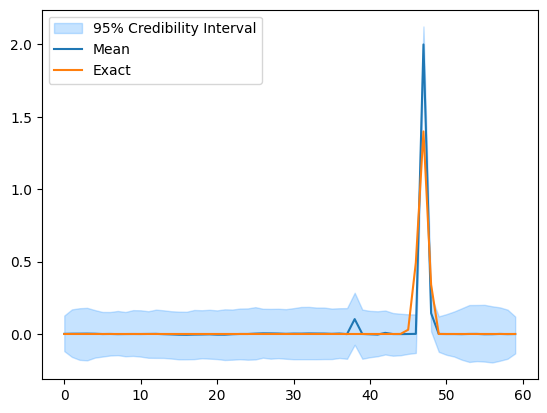

In [9]:
samples.plot_ci(exact=phi_true)

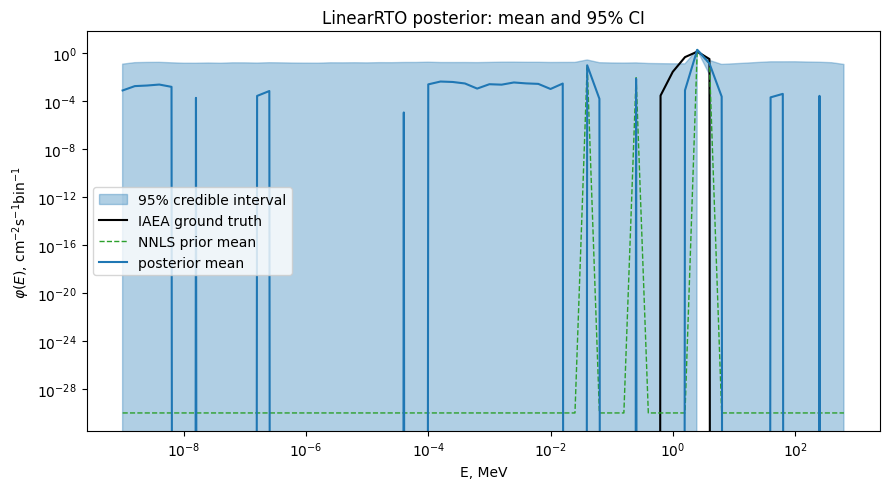

In [10]:
# same bands on log-log axes, plus the NNLS prior mean for reference
q_lo, q_hi = np.percentile(samples.samples, [2.5, 97.5], axis=1)

fig, ax = plt.subplots(figsize=(9, 5))
ax.fill_between(E, q_lo, q_hi, color="C0", alpha=0.35,
                label="95% credible interval")
ax.loglog(E, phi_true, "k-", lw=1.5, label="IAEA ground truth")
ax.loglog(E, mu_nnls, "C2--", lw=1, label="NNLS prior mean")
ax.loglog(E, samples.mean(), "C0-", lw=1.5, label="posterior mean")
ax.set(xlabel="E, MeV", ylabel=r"$\varphi(E)$, cm$^{-2}$s$^{-1}$bin$^{-1}$",
       title="LinearRTO posterior: mean and 95% CI")
ax.legend()
plt.tight_layout();

## Unknown noise level

Real Bonner sphere readings rarely come with an exactly known noise level.
Following the tutorial, we now treat the **precision** $s = 1/\sigma^2$ as
unknown and give it a conjugate Gamma hyperprior:

$$
s \sim \mathrm{Gamma}(1,\, 10^{-4}), \qquad
b \mid \varphi, s \sim \mathcal{N}(A\varphi,\, s^{-1} I).
$$

CUQI's automatic strategy for this model is a **HybridGibbs** sampler:
the spectrum block is updated with LinearRTO while the precision $s$ gets
an exact conjugate (Gibbs) update.

In [11]:
s = cuqi.distribution.Gamma(1, 1e-4)
y = cuqi.distribution.Gaussian(Alin @ x, prec=lambda s: s)

BP = cuqi.problem.BayesianProblem(y, x, s)
print(BP)

BayesianProblem with target: 
 JointDistribution(
    Equation: 
	p(y,x,s) = p(y|s,x)p(x)p(s)
    Densities: 
	y ~ CUQI Gaussian. Conditioning variables ['x', 's'].
	x ~ CUQI GMRF.
	s ~ CUQI Gamma.
 )


In [12]:
BP.set_data(y=b_noisy)
print(BP)

BayesianProblem with target: 
 JointDistribution(
    Equation: 
	p(x,s|y) ∝ L(s,x|y)p(x)p(s)
    Densities: 
	y ~ CUQI Gaussian Likelihood function. Parameters ['x', 's'].
	x ~ CUQI GMRF.
	s ~ CUQI Gamma.
 )


In [13]:
samples = BP.sample_posterior(2000)

!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
!!! Automatic sampler selection is a work-in-progress. !!!
!!!       Always validate the computed results.        !!!
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!

Using cuqi.sampler HybridGibbs sampler
burn-in: 20%

Automatically determined sampling strategy:
	x: LinearRTO (mcmc.sampler)
	s: Conjugate (mcmc.sampler)



Sample:   0%|          | 0/2000 [00:00<?, ?it/s]

Sample:   1%|▏         | 29/2000 [00:00<00:07, 281.18it/s]

Sample:   3%|▎         | 58/2000 [00:00<00:07, 274.27it/s]

Sample:   4%|▍         | 86/2000 [00:00<00:07, 264.74it/s]

...

Sample:  97%|█████████▋| 1940/2000 [00:06<00:00, 282.11it/s]

Sample:  98%|█████████▊| 1969/2000 [00:07<00:00, 282.42it/s]

Sample: 100%|█████████▉| 1998/2000 [00:07<00:00, 282.76it/s]

Sample: 100%|██████████| 2000/2000 [00:07<00:00, 278.45it/s]

Elapsed time: 8.66879415512085


array([[<Axes: title={'center': 's'}>, <Axes: title={'center': 's'}>]],
      dtype=object)

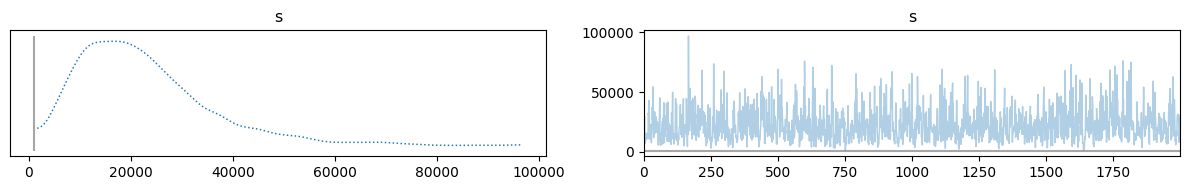

In [14]:
# the true precision is 1/0.03^2 ≈ 1111 — check the hyperposterior
samples["s"].plot_trace(exact=1 / noise_rel**2)

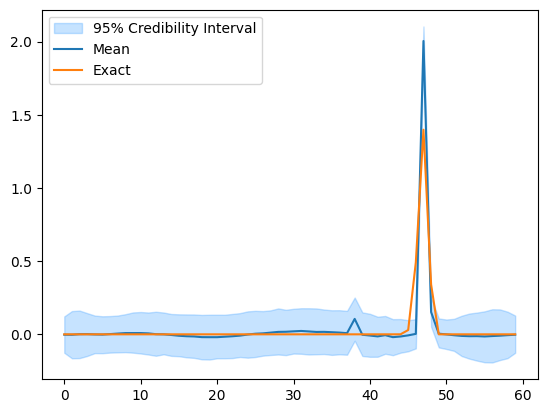

In [15]:
samples["x"].plot_ci(exact=phi_true)

## Strict non-negativity: the built-in `unfold_cuqi` wrapper

The linear Gaussian model above can assign negative fluence to weakly
constrained bins. `bssunfold`'s built-in
[`Detector.unfold_cuqi`](https://github.com/Radiationsafety/bssunfold/blob/bssunfold/docs/cuqi_bayes.rst)
solves the same problem with a **log-parameterisation**
$\varphi = \exp(\theta)$ — non-negativity by construction — and a
GMRF prior on $\theta$ anchored on the NNLS center. The smoothness
precision can itself be inferred through a conjugate Gamma hyperprior
(`hierarchical=True`), and the result carries full diagnostics
(HPD credible intervals, ESS, Gelman-Rubin $\hat{R}$, acceptance rates).

In [16]:
res = detector.unfold_cuqi(
    readings,
    sampler="gibbs_nuts",   # hierarchical HybridGibbs: NUTS block + conjugate delta update
    prior="gmrf",
    gmrf_order=1,
    hierarchical=True,
    n_samples=1000,
    n_burnin=500,
    chains=2,               # >= 2 chains enable the Gelman-Rubin diagnostic
    credible_level=95.0,
    random_state=42,
    progressbar=False,
)

stats = res["cuqi_stats"]
print(f"acceptance rate : {stats['acc_rate']:.2f}")
print(f"min ESS         : {np.nanmin(stats['ess']):.0f}")
print(f"max R-hat       : {np.nanmax(stats['rhat']):.2f}  "
      "(< 1.1 desired; slow-mixing hyperparameter needs longer runs)")

Sample:   0%|          | 0/1000 [00:00<?, ?it/s]

Sample:   0%|          | 2/1000 [00:00<01:00, 16.38it/s]

Sample:   0%|          | 4/1000 [00:00<01:19, 12.54it/s]

Sample:   1%|          | 6/1000 [00:00<01:44,  9.50it/s]

Sample:   1%|          | 8/1000 [00:00<01:53,  8.76it/s]

...

Sample:  97%|█████████▋| 968/1000 [00:23<00:00, 115.87it/s]

Sample:  98%|█████████▊| 980/1000 [00:23<00:00, 111.55it/s]

Sample: 100%|██████████| 1000/1000 [00:23<00:00, 132.27it/s]

Sample: 100%|██████████| 1000/1000 [00:23<00:00, 42.00it/s] 

acceptance rate : 0.67
min ESS         : 80
max R-hat       : 1.02  (< 1.1 desired; slow-mixing hyperparameter needs longer runs)


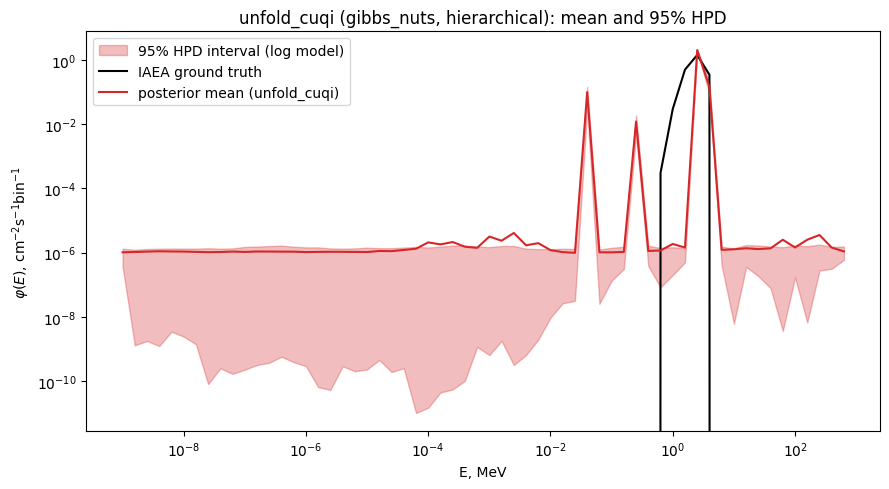

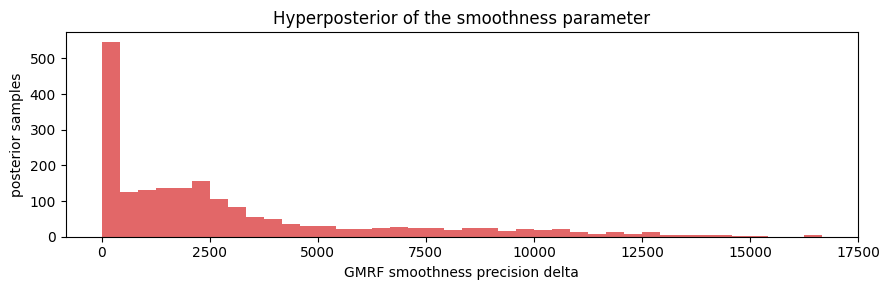

In [17]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.fill_between(E, res["spectrum_lower"], res["spectrum_upper"],
                color="C3", alpha=0.30, label="95% HPD interval (log model)")
ax.loglog(E, phi_true, "k-", lw=1.5, label="IAEA ground truth")
ax.loglog(E, res["spectrum"], "C3-", lw=1.5, label="posterior mean (unfold_cuqi)")
ax.set(xlabel="E, MeV", ylabel=r"$\varphi(E)$, cm$^{-2}$s$^{-1}$bin$^{-1}$",
       title="unfold_cuqi (gibbs_nuts, hierarchical): mean and 95% HPD")
ax.legend()
plt.tight_layout();

fig, ax = plt.subplots(figsize=(9, 3))
ax.hist(np.asarray(stats["delta_samples"]), bins=40, color="C3", alpha=0.7)
ax.set(xlabel="GMRF smoothness precision delta", ylabel="posterior samples",
       title="Hyperposterior of the smoothness parameter")
plt.tight_layout();

## Quantitative comparison of the three posterior estimates

In [18]:
# fixed-noise posterior mean (LinearRTO, as in the first part)
y_fixed = cuqi.distribution.Gaussian(Alin @ x, noise_rel**2)
BP_fixed = cuqi.problem.BayesianProblem(y_fixed, x)
BP_fixed.set_data(y_fixed=b_noisy)
fixed_mean = BP_fixed.sample_posterior(2000).mean()

estimates = {
    "LinearRTO (fixed noise)": fixed_mean,
    "HybridGibbs (unknown noise)": samples["x"].mean(),
    "unfold_cuqi (log model)": res["spectrum"],
}

for label, spec in estimates.items():
    q = compare_spectra(np.asarray(spec), phi_true,
                        metrics=["pearson_r", "relative_flux_error",
                                 "comprehensive_score"])
    print(f"{label:30s} pearson_r = {q['pearson_r']:+.3f}   "
          f"rel. flux error = {q['relative_flux_error']:.3f}   "
          f"score = {q['comprehensive_score']:.3f}")

!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
!!! Automatic sampler selection is a work-in-progress. !!!
!!!       Always validate the computed results.        !!!
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!

Using cuqi.sampler LinearRTO sampler.
burn-in: 20%


Sample:   0%|          | 0/2000 [00:00<?, ?it/s]

Sample:   0%|          | 0/2000 [00:00<?, ?it/s, acc rate: 100.00%]

Sample:   0%|          | 0/2000 [00:00<?, ?it/s, acc rate: 100.00%]

Sample:   0%|          | 0/2000 [00:00<?, ?it/s, acc rate: 100.00%]

...

Sample:  98%|█████████▊| 1963/2000 [00:04<00:00, 389.25it/s, acc rate: 100.00%]

Sample:  98%|█████████▊| 1963/2000 [00:04<00:00, 389.25it/s, acc rate: 100.00%]

Sample:  98%|█████████▊| 1963/2000 [00:04<00:00, 389.25it/s, acc rate: 100.00%]

Sample: 100%|██████████| 2000/2000 [00:04<00:00, 407.74it/s, acc rate: 100.00%]

Elapsed time: 5.816824674606323
LinearRTO (fixed noise)        pearson_r = +0.930   rel. flux error = 0.403   score = -0.062
HybridGibbs (unknown noise)    pearson_r = +0.931   rel. flux error = 0.404   score = -0.062
unfold_cuqi (log model)        pearson_r = +0.931   rel. flux error = 0.403   score = -0.063


## Summary

- The **Gaussian + GMRF** Bayesian model of the unfolding problem is
  sampled with CUQIpy exactly as in the deconvolution tutorial:
  `BayesianProblem` → `set_data` → `sample_posterior`, with LinearRTO
  chosen automatically and **HybridGibbs + conjugate updates** when the
  noise precision is unknown.
- The posterior samples turn the classic point estimate into
  **per-bin credible intervals** that honestly reflect the
  information content of the 10 sphere readings.
- For a strictly non-negative spectrum use the built-in
  `Detector.unfold_cuqi` (log-parameterisation, GMRF/OU priors,
  hierarchical Gibbs, ESS / $\hat{R}$ / HPD diagnostics) — see
  `docs/cuqi_bayes.rst` and the method reference table (row 80) in the
  README.

**References**
- CUQIpy: [CUQI-DTU/CUQIpy](https://github.com/CUQI-DTU/CUQIpy) and the
  [UQ in deconvolution 1D tutorial](https://cuqi-dtu.github.io/CUQIpy/user/_auto_howtos/uq_in_deconvolution_1d.html).
- IAEA: *Compendium of Neutron Spectra and Detector Responses*,
  https://www-nds.iaea.org/benchmarks/.